## Overview of the Data

The dataset that contains information about customers such as demographic information, purchasing history, and customer interactions.

InvoiceNo: The invoice number for each transaction

StockCode: The unique code for each product sold

Description: The description of each product sold

Quantity: The quantity of each product sold in each transaction

InvoiceDate: The date and time of each transaction

UnitPrice: The price of each product sold

CustomerID: The unique identifier for each customer

Country: The country where each transaction occurred

In [1]:
#Dataset
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx


--2025-05-01 22:12:31--  https://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Online Retail.xlsx.1’

Online Retail.xlsx.     [     <=>            ]  22.62M  24.2MB/s    in 0.9s    

2025-05-01 22:12:32 (24.2 MB/s) - ‘Online Retail.xlsx.1’ saved [23715344]



### Import the packages and Load the dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline


# For CSV
# df = pd.read_csv('OnlineRetail.csv')

# For Excel
df = pd.read_excel('Online Retail.xlsx')
df.head()


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [2]:
df.shape

(541909, 8)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Preparing the data

In [4]:
# Remove missing CustomerIDs
df = df.dropna(subset=['CustomerID'])

# Convert CustomerID to string
df['CustomerID'] = df['CustomerID'].astype(np.int64)


df['CustomerID'] = df['CustomerID'].astype(str)

# Create a new column for Order Value
df['OrderValue'] = df['Quantity'] * df['UnitPrice']

In [5]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,OrderValue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 406829 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    406829 non-null  object        
 1   StockCode    406829 non-null  object        
 2   Description  406829 non-null  object        
 3   Quantity     406829 non-null  int64         
 4   InvoiceDate  406829 non-null  datetime64[ns]
 5   UnitPrice    406829 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      406829 non-null  object        
 8   OrderValue   406829 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(5)
memory usage: 31.0+ MB


In [7]:
import sqlite3

# Create in-memory database
conn = sqlite3.connect(':memory:')
df.to_sql('retail', conn, index=False, if_exists='replace')

406829

## Analysis

### Q1. Distribution of Order Values

In [8]:
query = """
SELECT CustomerID, SUM(Quantity * UnitPrice) as TotalOrderValue
FROM retail
GROUP BY CustomerID
ORDER BY TotalOrderValue DESC
"""
order_values = pd.read_sql(query, conn)
order_values.head()

,CustomerID,TotalOrderValue
0,14646,279489.02
1,18102,256438.49
2,17450,187482.17
3,14911,132572.62
4,12415,123725.45


The distribution of total order values is highly skewed, with most customers placing relatively low-value orders.

In [9]:
order_values.shape

(4372, 2)

### Q2. Unique Products Purchased by Each Customer

In [10]:
query = """
SELECT CustomerID, COUNT(DISTINCT StockCode) as UniqueProducts
FROM retail
GROUP BY CustomerID
ORDER BY UniqueProducts DESC
"""
unique_products = pd.read_sql(query, conn)
unique_products.head()

,CustomerID,UniqueProducts
0,14911,1794
1,12748,1769
2,17841,1331
3,14096,1121
4,14298,884


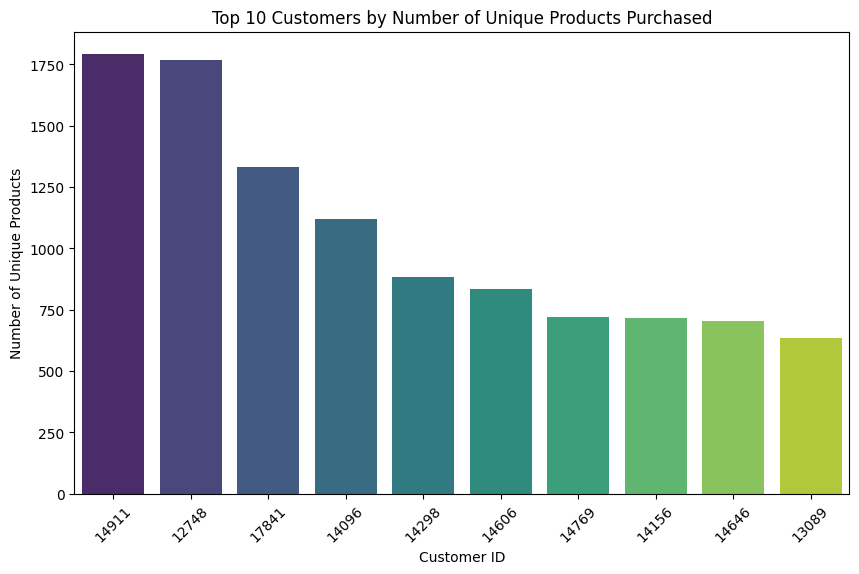

In [11]:
top_customers = unique_products.sort_values(by='UniqueProducts', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='CustomerID', y='UniqueProducts', palette='viridis')
plt.title('Top 10 Customers by Number of Unique Products Purchased')
plt.xlabel('Customer ID')
plt.ylabel('Number of Unique Products')
plt.xticks(rotation=45)
plt.show()

The top 10 customers bought significantly more unique items — possibly indicating wholesalers or loyal bulk buyers.

### Q3. Customers with only one Purchase

In [12]:
query = """
SELECT CustomerID, COUNT(DISTINCT InvoiceNo) as NumberOfPurchases
FROM retail
GROUP BY CustomerID
HAVING NumberOfPurchases = 1
"""
one_time_customers = pd.read_sql(query, conn)
one_time_customers.head()

,CustomerID,NumberOfPurchases
0,12349,1
1,12350,1
2,12353,1
3,12354,1
4,12355,1


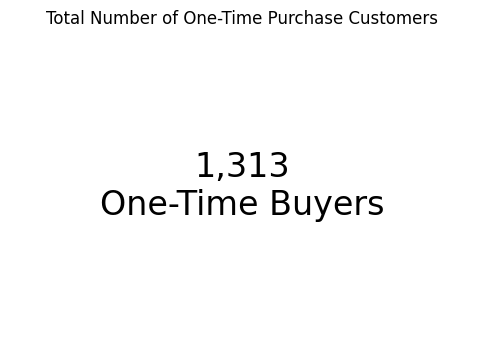

In [13]:
plt.figure(figsize=(6, 4))
count = one_time_customers.shape[0]
plt.text(0.5, 0.5, f'{count:,}\nOne-Time Buyers', fontsize=24, ha='center', va='center')
plt.axis('off')
plt.title('Total Number of One-Time Purchase Customers')
plt.show()

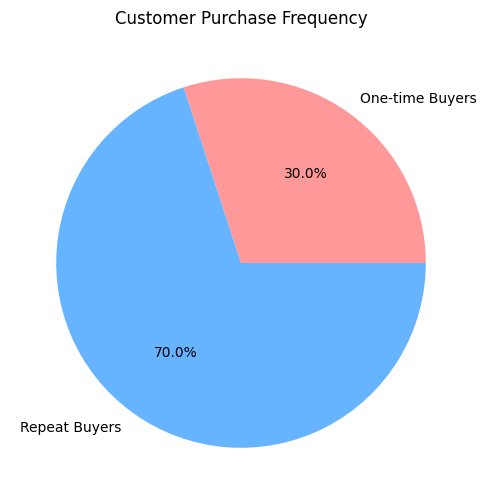

In [14]:
import numpy as np

multi_buyers_count = order_values.shape[0] - count
labels = ['One-time Buyers', 'Repeat Buyers']
sizes = [count, multi_buyers_count]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Customer Purchase Frequency')
plt.show()


### Q4. Products Most Commonly Purchased Together

In [15]:
# used to identify pairs of products that are frequently purchased together in the same transaction.
#It’s a basic form of market basket analysis.

query = """
SELECT a.StockCode as Product1, b.StockCode as Product2, COUNT(*) as Frequency
FROM retail a
JOIN retail b
ON a.InvoiceNo = b.InvoiceNo AND a.StockCode < b.StockCode
GROUP BY Product1, Product2
ORDER BY Frequency DESC
LIMIT 10
"""
product_pairs = pd.read_sql(query, conn)
product_pairs.head()

,Product1,Product2,Frequency
0,22697,22698,732
1,22697,22699,634
2,22726,22727,600
3,22386,85099B,587
4,20725,20727,577


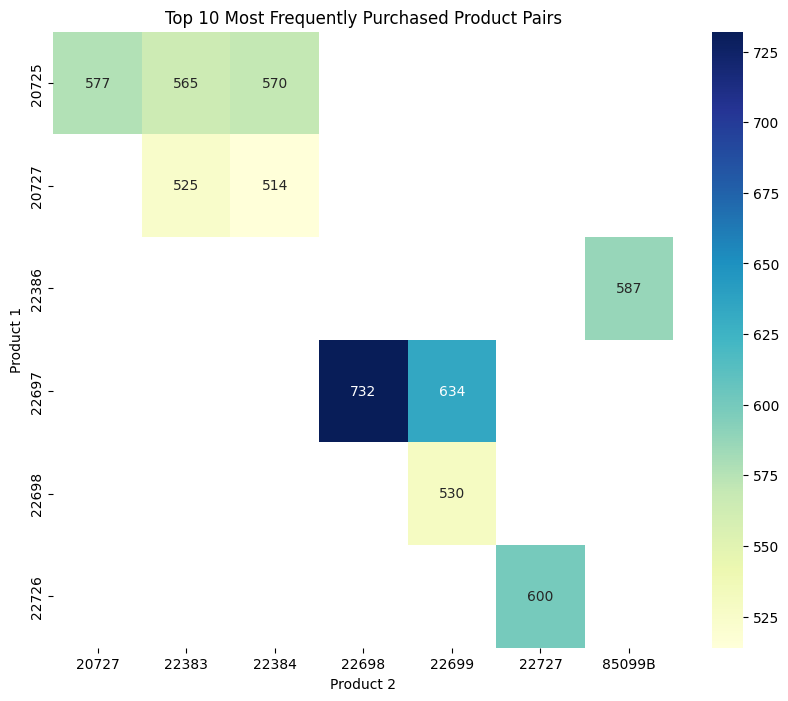

In [16]:
# Pivot the table to create a matrix
pair_matrix = product_pairs.pivot(index='Product1', columns='Product2', values='Frequency')

plt.figure(figsize=(10,8))
sns.heatmap(pair_matrix, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title('Top 10 Most Frequently Purchased Product Pairs')
plt.xlabel('Product 2')
plt.ylabel('Product 1')
plt.show()

### Q5. Countries with High Purchasing Customers

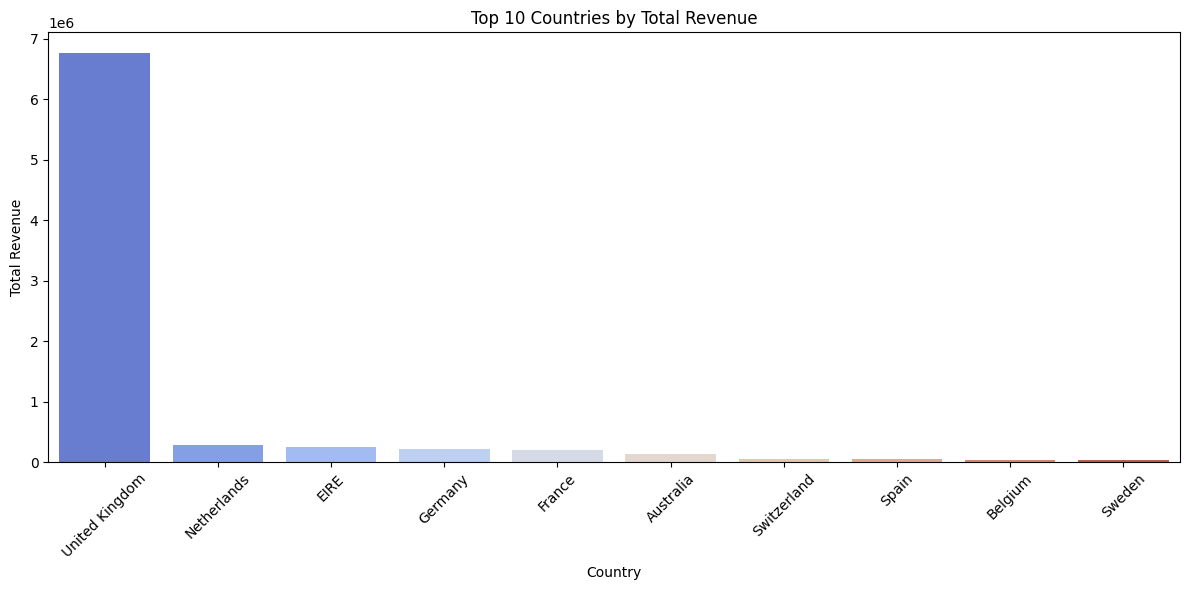

In [17]:
query =  """

SELECT Country,
       COUNT(DISTINCT CustomerID) AS Num_Customers,
       SUM(Quantity * UnitPrice) AS TotalRevenue
FROM retail
WHERE CustomerID IS NOT NULL
GROUP BY Country
ORDER BY TotalRevenue DESC
"""
country_data = pd.read_sql(query, conn)

# Top 10 countries by revenue
top_countries = country_data.head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(data=top_countries, x='Country', y='TotalRevenue', palette='coolwarm')
plt.title('Top 10 Countries by Total Revenue')
plt.xlabel('Country')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The United Kingdom (UK) typically contributes the highest revenue and customer volume, likely because the business is UK-based.